# Python implement greedy search and A* in the maze
import numpy as np
import matplotlib.pyplot as plt
import heapq

# Maze
maze = np.array([
    [1,0,1,1,1,0,1,1,1,0,1,1],
    [1,0,1,1,1,0,1,1,1,0,1,1],
    [0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,0,0,0,0,1,0,0,0,1,0],
    [0,1,0,1,1,0,1,0,1,0,1,0],
    [0,1,0,0,1,0,1,0,1,0,1,0],
    [0,1,0,1,1,0,1,0,1,0,1,0],
    [0,1,0,0,1,0,1,0,1,0,1,0],
    [0,1,0,1,1,0,1,0,1,0,0,0],
    [0,0,0,0,1,0,0,0,1,0,1,1]
])

start = (10, 0)
goal = (9, 11)

rows, cols = maze.shape



def heuristic(a, b):

    return abs(a[0] - b[0]) + abs(a[1] - b[1])



a → current position (row, col)
b → goal position (row, col)
a[0] = row, a[1] = column
So:

abs(a[0] - b[0]) → vertical distance
abs(a[1] - b[1]) → horizontal distance


Use heapq and explore nodes with the lowest heuristics. 

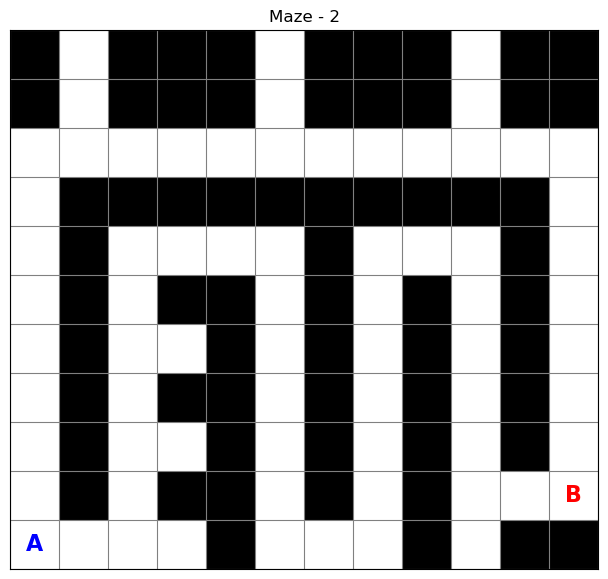

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

# Maze
maze = np.array([
    [1,0,1,1,1,0,1,1,1,0,1,1],
    [1,0,1,1,1,0,1,1,1,0,1,1],
    [0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,0],
    [0,1,0,0,0,0,1,0,0,0,1,0],
    [0,1,0,1,1,0,1,0,1,0,1,0],
    [0,1,0,0,1,0,1,0,1,0,1,0],
    [0,1,0,1,1,0,1,0,1,0,1,0],
    [0,1,0,0,1,0,1,0,1,0,1,0],
    [0,1,0,1,1,0,1,0,1,0,0,0],
    [0,0,0,0,1,0,0,0,1,0,1,1]
])

start = (10, 0)
goal = (9, 11)

rows, cols = maze.shape


# Plot
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(maze, cmap="gray_r", interpolation="nearest")

# Draw borders around every cell
rows, cols = maze.shape
ax.set_xticks(np.arange(-0.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, rows, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

# Labels
ax.text(start[1], start[0], "A", ha="center", va="center", color="blue", fontsize=16, fontweight="bold")
ax.text(goal[1], goal[0], "B", ha="center", va="center", color="red", fontsize=16, fontweight="bold")

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Maze - 2")
plt.show()

In [13]:
#Find the nodes and edges
#Make a function to calculate heuristics
#Add print the heuristics for each available nodes "0" nodes

possible_direction = ((0,1),(0,-1),(1,0),(-1,0))
graph ={}
edges = []

for row, col in nodes:
    current = (row, col)
    neighbors = []
    for d_row, d_col in possible_direction:
        next_row = row + d_row
        next_col = col + d_col
        if 0 <= next_row < rows and 0 <= next_col < cols and maze[next_row, next_col] == 0:
            neighbor = (next_row, next_col)
            neighbors.append(neighbor)
            if current < neighbor:
                edges.append((current, neighbor))
        graph[current] = neighbors

In [14]:
import heapq # Priority Queue implementation -> lower at left
def heuristic (node, goal):
    return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

In [15]:
def greedy_search (graph, start, goal):
    visited = set()
    parent ={}

    pq=[]
    heapq.heappush(pq, (heuristic(start, goal), start))
    while pq:
        _, current = heapq.heappop(pq)
        if current == goal:
            break

        if current in visited:
            continue
        visited.add(current)
        for neighbor in graph [current]:
            if neighbor not in visited:
                parent[neighbor] = current
                heapq.heappush(pq, (heuristic(neighbor, goal), neighbor))

    #reconstruct path